# GMM Exploration on the Michelson data

Now that we have the Michelson data in a good position, we can start working on the GMM to help quantify some distance, with some additions. 

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.mixture import GaussianMixture
import helpers.generate_planet_list as helpers
import helpers.generate_galaxy_data as galaxy_helpers
import helpers.color_color_plots as ccp
from helpers.gmm_classify import GMMClassifier, balanced_accuracy, fit_and_score
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

randomSeed = 2

SpeciesInit()
db = Database()

db.add_model('sonora-bobcat', wavel_range=(0.61, 17.0), wavel_sampling=1000.0)

bobcat_model = ReadModel('sonora-bobcat')
bobcat_planets = helpers.generate_planet_arrays(bobcat_model, radius_range=(0.6, 1.3), distance=10, num_samples=800, rng=randomSeed)

bobcat_planets = helpers.update_planet_flux_and_magnitude(bobcat_model, bobcat_planets, ['JWST/MIRI.F1065C', 'JWST/MIRI.F1140C', 'JWST/MIRI.F1550C'])
bobcat_planets = helpers.add_color_columns(bobcat_planets, ['F1065C', 'F1140C', 'F1550C'])
names, colors = helpers.color_color_matrix(bobcat_planets)

AGN_00_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR0.0.txt')
AGN_05_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR0.5.txt')
AGN_10_data = galaxy_helpers.galaxy_color_color_data_k15('./galaxy-data/K15_templates/MIR_library/MIR1.0.txt')
# get all of the dwarf planet colors for the first color

d_color_1 = colors[:, 0]
d_color_2 = colors[:, 1]
d_color_3 = colors[:, 2]

g_00_color_1 = AGN_00_data[names[0]]
g_05_color_1 = AGN_05_data[names[0]]
g_10_color_1 = AGN_10_data[names[0]]

g_00_color_2 = AGN_00_data[names[1]]
g_05_color_2 = AGN_05_data[names[1]]
g_10_color_2 = AGN_10_data[names[1]]

g_00_color_3 = AGN_00_data[names[2]]
g_05_color_3 = AGN_05_data[names[2]]
g_10_color_3 = AGN_10_data[names[2]]

all_g_color_1 = np.concatenate((g_00_color_1, g_05_color_1, g_10_color_1))
all_g_color_2 = np.concatenate((g_00_color_2, g_05_color_2, g_10_color_2))
all_g_color_3 = np.concatenate((g_00_color_3, g_05_color_3, g_10_color_3))

all_color_1 = np.concatenate((d_color_1, all_g_color_1))
all_color_2 = np.concatenate((d_color_2, all_g_color_2))
all_color_3 = np.concatenate((d_color_3, all_g_color_3))

X = np.column_stack((all_color_1, all_color_2))
Y = np.concatenate((np.zeros(len(d_color_1)), np.ones(len(all_g_color_1))))

# Carry the original row indices through the split. Dwarf rows occupy
# positions 0 .. len(d_color_1)-1 of X, in the same order as bobcat_planets'
# arrays (teff, radius, ...), so idx_test lets the "which dwarfs fail" cell
# below trace a misclassified test point straight back to its T_eff.
idx = np.arange(len(X))
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X, Y, idx, stratify=Y, random_state=0)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed

-------------------------
Add grid of model spectra
-------------------------

Database tag: sonora-bobcat
Model name: Sonora Bobcat

Unpacking 1131/1131 model spectra from Sonora Bobcat (392 MB)... [DONE]

Please cite Marley et al. (2021) when using Sonora Bobcat in a publication
Reference URL: https://zenodo.org/record/5063476

Wavelength range (um) = 0.61 - 17.0
Sampling (lambda/d_lambda) = 1000.0
Teff range (K) = 200 - 2400

Adding Sonora Bobcat model spectra... data/

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:413: RuntimeWarning: divide by zero encountered in log10
  flux = np.log10(flux)


## Choosing the number of components (BIC)

BIC trades fit quality against model complexity, so it penalizes adding
components that don't earn their keep -- lower is better. Sweep `K` and fit a
fresh `GMMClassifier` at each value (same `random_state=0`, same `X_train`),
scoring BIC on the held-out `X_test`, the same convention the fit cell below
uses. This is what justifies the `K` picked there rather than asserting it.

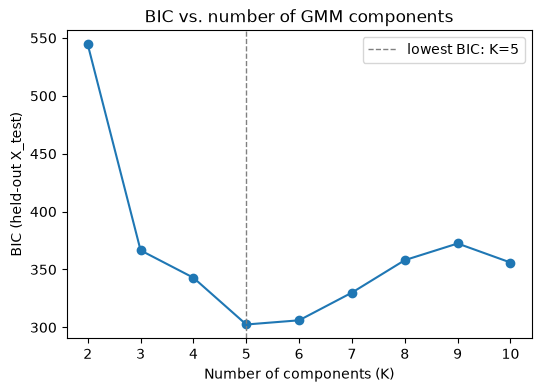

K= 2  BIC= 544.3857
K= 3  BIC= 366.5300
K= 4  BIC= 342.8783
K= 5  BIC= 302.4790  <-- lowest BIC
K= 6  BIC= 306.1037
K= 7  BIC= 330.0337
K= 8  BIC= 358.0731
K= 9  BIC= 372.4678
K=10  BIC= 356.0230


In [4]:
K_candidates = range(2, 11)
bic_scores = []
for k in K_candidates:
    candidate = GMMClassifier(n_components=k, random_state=0).fit(X_train, Y_train)
    bic_scores.append(candidate.bic(X_test))

best_k = K_candidates[int(np.argmin(bic_scores))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_candidates), bic_scores, marker="o")
ax.axvline(best_k, color="0.5", linestyle="--", linewidth=1,
           label=f"lowest BIC: K={best_k}")
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC (held-out X_test)")
ax.set_title("BIC vs. number of GMM components")
ax.legend()
plt.show()

for k, bic_val in zip(K_candidates, bic_scores):
    flag = "  <-- lowest BIC" if k == best_k else ""
    print(f"K={k:2d}  BIC={bic_val:9.4f}{flag}")

BIC: 302.4790
Balanced accuracy score: 0.9632


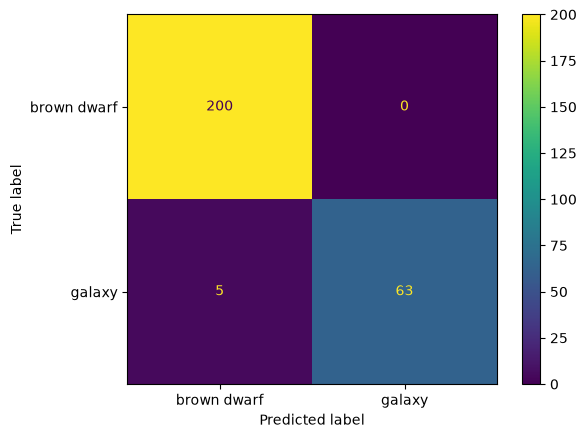

In [5]:
# Number of Gaussian components. The dwarfs trace a T_eff curve and the
# galaxies trace redshift curves, not single blobs -- K > n_classes lets the
# fit tile each curve with several small Gaussians instead of approximating
# it with one badly-oriented ellipse per class. GMMClassifier fits unlabeled
# (labels only decide, after the fact, which class each component belongs
# to), so K need not equal 2.
K = 5

clf = GMMClassifier(n_components=K, random_state=0).fit(X_train, Y_train)
pred_best = clf.predict(X_test)
score = clf.score(X_test, Y_test)

matrix = ConfusionMatrixDisplay.from_predictions(
    Y_test, pred_best, display_labels=["brown dwarf", "galaxy"]
)

bic = clf.bic(X_test)
print(f"BIC: {bic:.4f}")
print(f"Balanced accuracy score: {score:.4f}")


## Component composition

Which of the K Gaussians are cleanly one class, and which are ambiguous.
`mass_class_*` is the class-balanced vote share each component drew from the
training set (see `component_class_map` in `helpers/gmm_classify.py`); `margin`
is top mass minus runner-up, so components near 0 are the ones splitting their
vote and worth a closer look. Sorted so the most ambiguous components float to
the top.

In [6]:
import pandas as pd

table = pd.DataFrame(clf.component_table(X_train, Y_train)).sort_values("margin")
table

,component,assigned_class,weight,margin,degenerate,mass_class_0.0,n_class_0.0,mass_class_1.0,n_class_1.0
3,3,0.0,0.208499,0.203699,False,2.588951e-01,138,5.519612e-02,11
4,4,0.0,0.253821,0.339407,False,3.394069e-01,205,1.189936e-42,0
2,2,1.0,0.088251,0.350003,False,4.837487e-30,0,3.500028e-01,73
0,0,0.0,0.303787,0.380138,False,4.002896e-01,257,2.015164e-02,4
1,1,1.0,0.145641,0.573241,False,1.408362e-03,0,5.746495e-01,114


## Decision regions

Shaded by predicted class, with each component's 2-sigma covariance ellipse
drawn on top (alpha scaled by the component's mixture weight). This is the
picture that answers whether the K components are actually tiling the dwarf
T_eff curve / galaxy redshift curves, or just cutting across them.

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:526: RuntimeWarning: divide by zero encountered in matmul
  y = (X @ prec_chol) - (mu @ prec_chol)
/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:526: RuntimeWarning: overflow encountered in matmul
  y = (X @ prec_chol) - (mu @ prec_chol)
/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:526: RuntimeWarning: invalid value encountered in matmul
  y = (X @ prec_chol) - (mu @ prec_chol)


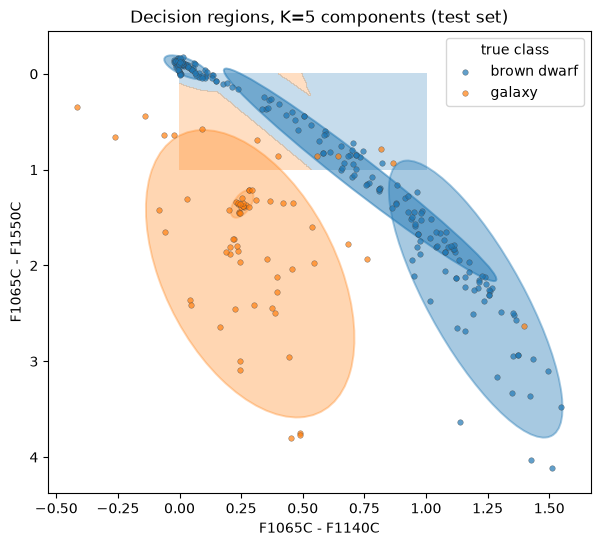

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

class_colors = ccp.class_color_map(clf.classes_)
ccp.plot_decision_regions(ax, clf, X_test, Y_test, class_colors=class_colors)
ccp.plot_component_ellipses(ax, clf.gm_, comp_to_class=clf.comp_to_class_,
                            class_colors=class_colors)
ccp.style_panel(ax, names[0], names[1])
ax.legend(["brown dwarf", "galaxy"], title="true class")
ax.set_title(f"Decision regions, K={K} components (test set)")
plt.show()

## Which dwarfs fail

Trace the misclassified test-set dwarfs back to `bobcat_planets` via `idx_test`
and look at where they sit in T_eff, to see whether failures cluster at one end
of the sequence (the open question from the 2026-08-05 log entry) or are spread
evenly.

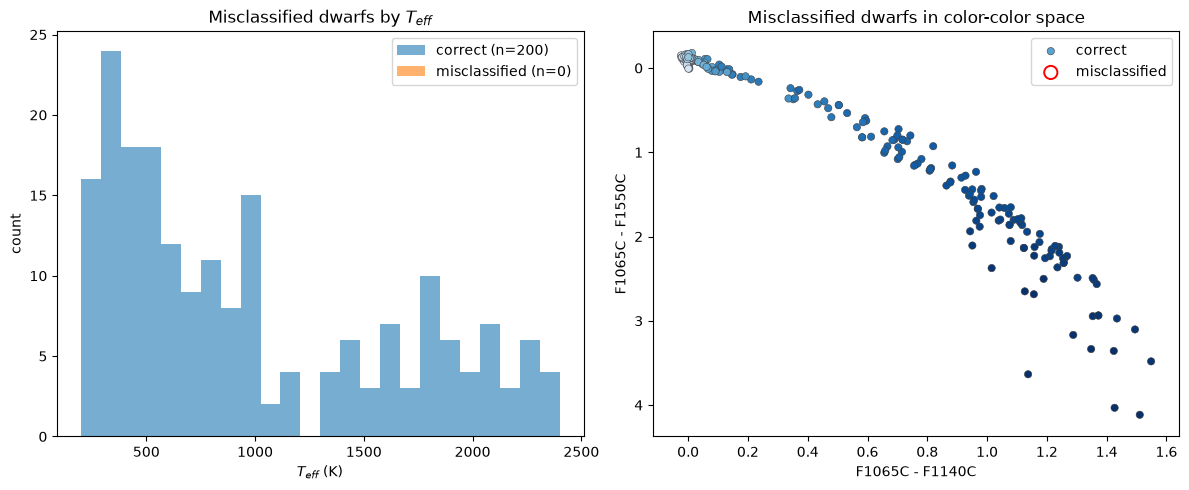

0 / 200 test-set dwarfs misclassified as galaxy


In [8]:
dwarf_mask = Y_test == 0
correct_idx = idx_test[dwarf_mask & (pred_best == 0)]
wrong_idx = idx_test[dwarf_mask & (pred_best != 0)]

teff_correct = bobcat_planets["teff"][correct_idx]
teff_wrong = bobcat_planets["teff"][wrong_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(bobcat_planets["teff"].min(), bobcat_planets["teff"].max(), 25)
axes[0].hist(teff_correct, bins=bins, alpha=0.6, label=f"correct (n={len(teff_correct)})")
axes[0].hist(teff_wrong, bins=bins, alpha=0.6, label=f"misclassified (n={len(teff_wrong)})")
axes[0].set_xlabel("$T_{eff}$ (K)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified dwarfs by $T_{eff}$")

axes[1].scatter(X_test[dwarf_mask, 0], X_test[dwarf_mask, 1],
               c=bobcat_planets["teff"][idx_test[dwarf_mask]], cmap=ccp.DWARF_CMAP,
               s=28, edgecolors="0.25", linewidths=0.4, zorder=3, label="correct")
axes[1].scatter(X_test[dwarf_mask & (pred_best != 0), 0],
               X_test[dwarf_mask & (pred_best != 0), 1],
               facecolors="none", edgecolors="red", s=90, linewidths=1.4,
               zorder=4, label="misclassified")
ccp.style_panel(axes[1], names[0], names[1])
axes[1].legend()
axes[1].set_title("Misclassified dwarfs in color-color space")

plt.tight_layout()
plt.show()

print(f"{len(wrong_idx)} / {dwarf_mask.sum()} test-set dwarfs misclassified as galaxy")


## Which galaxies fail

The galaxy-side counterpart to the dwarf check above. Galaxies don't have a
T_eff, but they do have the axis their track is built along: redshift, plus
which K15 AGN-fraction template (0.0 / 0.5 / 1.0) they came from. Trace the
misclassified test-set galaxies back to both via `idx_test`, using the same
`g_00_color_1` / `g_05_color_1` / `g_10_color_1` concatenation order that built
`X` in the setup cell.

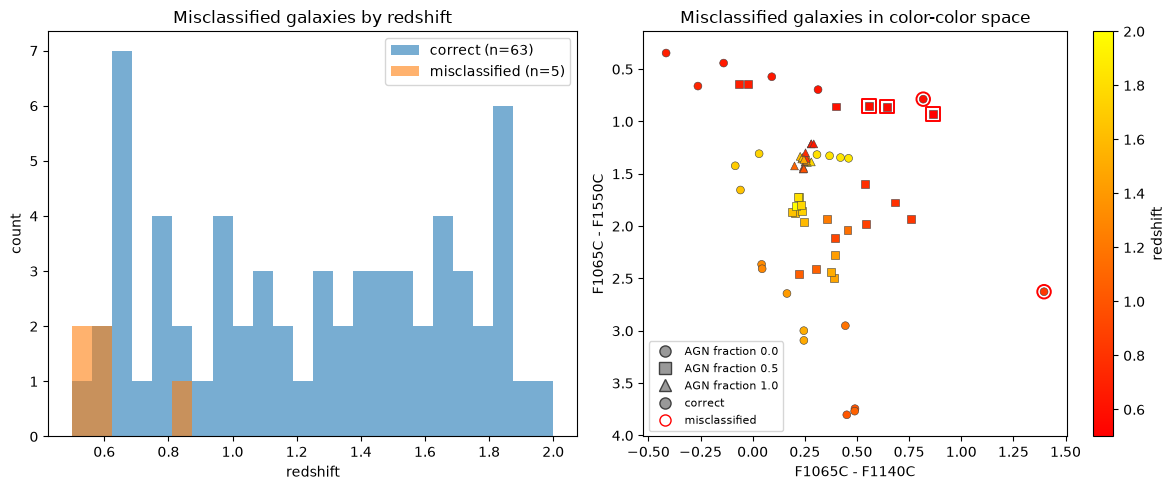

5 / 68 test-set galaxies misclassified as brown dwarf
AGN fraction 0.0: 2 / 23 misclassified
AGN fraction 0.5: 3 / 26 misclassified
AGN fraction 1.0: 0 / 19 misclassified


In [9]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

galaxy_offset = len(d_color_1)
all_g_redshift = np.concatenate((AGN_00_data["redshift"], AGN_05_data["redshift"], AGN_10_data["redshift"]))
all_g_agn_frac = np.concatenate((
    np.full(len(g_00_color_1), 0.0),
    np.full(len(g_05_color_1), 0.5),
    np.full(len(g_10_color_1), 1.0),
))

galaxy_mask = Y_test == 1
galaxy_local_idx = idx_test[galaxy_mask] - galaxy_offset
z_test = all_g_redshift[galaxy_local_idx]
agn_frac_test = all_g_agn_frac[galaxy_local_idx]
wrong_mask = pred_best[galaxy_mask] != 1

correct_idx_g = idx_test[galaxy_mask & (pred_best == 1)]
wrong_idx_g = idx_test[galaxy_mask & (pred_best != 1)]

z_correct = all_g_redshift[correct_idx_g - galaxy_offset]
z_wrong = all_g_redshift[wrong_idx_g - galaxy_offset]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(all_g_redshift.min(), all_g_redshift.max(), 25)
axes[0].hist(z_correct, bins=bins, alpha=0.6, label=f"correct (n={len(z_correct)})")
axes[0].hist(z_wrong, bins=bins, alpha=0.6, label=f"misclassified (n={len(z_wrong)})")
axes[0].set_xlabel("redshift")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified galaxies by redshift")

# AGN fraction is categorical (0.0/0.5/1.0), so it gets its own visual channel
# (marker shape) rather than fighting redshift for the color scale. All three
# shapes share one Normalize so the colorbar means the same thing for each.
agn_markers = {0.0: "o", 0.5: "s", 1.0: "^"}
norm = Normalize(vmin=all_g_redshift.min(), vmax=all_g_redshift.max())
x_test_g = X_test[galaxy_mask, 0]
y_test_g = X_test[galaxy_mask, 1]

for frac, marker in agn_markers.items():
    frac_mask = agn_frac_test == frac
    z_handle = axes[1].scatter(
        x_test_g[frac_mask], y_test_g[frac_mask], c=z_test[frac_mask],
        cmap=ccp.GALAXY_CMAP, norm=norm, marker=marker, s=32,
        edgecolors="0.25", linewidths=0.4, zorder=3)
    axes[1].scatter(
        x_test_g[frac_mask & wrong_mask], y_test_g[frac_mask & wrong_mask],
        facecolors="none", edgecolors="red", marker=marker, s=95,
        linewidths=1.4, zorder=4)

ccp.style_panel(axes[1], names[0], names[1])
shape_handles = [Line2D([], [], marker=marker, linestyle="none", markerfacecolor="0.6",
                        markeredgecolor="0.25", markersize=8, label=f"AGN fraction {frac}")
                 for frac, marker in agn_markers.items()]
status_handles = [
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="0.6",
           markeredgecolor="0.25", markersize=8, label="correct"),
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="red", markersize=8, label="misclassified"),
]
axes[1].legend(handles=shape_handles + status_handles, fontsize=8, loc="best")
axes[1].set_title("Misclassified galaxies in color-color space")
fig.colorbar(z_handle, ax=axes[1], label="redshift")

plt.tight_layout()
plt.show()

print(f"{len(wrong_idx_g)} / {galaxy_mask.sum()} test-set galaxies misclassified as brown dwarf")

for frac in (0.0, 0.5, 1.0):
    n_total = np.sum(agn_frac_test == frac)
    n_wrong = np.sum(agn_frac_test[wrong_mask] == frac)
    print(f"AGN fraction {frac}: {n_wrong} / {n_total} misclassified")

In [10]:
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(X, Y, test_size=0.4,
                                          stratify=Y, random_state=seed)
    score, _ = fit_and_score(Xtr, ytr, Xte, yte, n_components=K, seed=seed)
    print(seed, round(score, 3))


0 0.961
1 0.954
2 0.972
3 0.98
4 0.926
5 0.954
6 0.969
7 0.977
8 0.963
9 0.939
10 0.966
11 0.954
12 0.98
13 0.977
14 0.96
15 0.975
16 0.946
17 0.957
18 0.977
19 0.985
